<a href="https://colab.research.google.com/github/bhalleaheesha/Data-Analyst-and-Data-Science-Projects/blob/main/HR_Fairness_Analytics_and_Employee_Risk_Assessment%20%5BData%20Science%20Project%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/HR Fairness Analytics Case Study.xlsx')
# Preview data
df.head()

,Factory,Job Role,Equality Score,Equality class,Role Level,Fairness Band,High Risk Flag,Employee Name
0,Daikibo Factory Meiyo,C-Level,-25,Highly Discriminative,Executive,Critical,Yes,Aadhya Iyer
1,Daikibo Factory Meiyo,VP,-26,Highly Discriminative,Executive,Critical,Yes,Rohan Chatterjee
2,Daikibo Factory Meiyo,Director,-19,Unfair,Senior Leadership,High Risk,Yes,Vivaan Banerjee
3,Daikibo Factory Meiyo,Sr. Manager,-15,Unfair,Mid Management,High Risk,Yes,Aarav Rao
4,Daikibo Factory Meiyo,Manager,-14,Unfair,Mid Management,High Risk,No,Saanvi Verma


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Factory         37 non-null     object
 1   Job Role        37 non-null     object
 2   Equality Score  37 non-null     int64 
 3   Equality class  37 non-null     object
 4   Role Level      37 non-null     object
 5   Fairness Band   37 non-null     object
 6   High Risk Flag  37 non-null     object
 7   Employee Name   37 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.4+ KB


In [ ]:
#This code Checks missing (null) values in each column
df.isnull().sum()

,0
Factory,0
Job Role,0
Equality Score,0
Equality class,0
Role Level,0
Fairness Band,0
High Risk Flag,0
Employee Name,0


In [ ]:
#This code removes duplicate rows from the dataset.
df = df.drop_duplicates()

In [ ]:
#This code removes extra spaces (whitespace) from the column names.
df.columns = df.columns.str.strip()

In [ ]:
# Unique values
print(df['Factory'].unique())
print(df['Job Role'].unique())

# Summary stats
df.describe()

['Daikibo Factory Meiyo' 'Daikibo Factory Seiko' 'Daikibo Berlin'
 'Daikibo Shenzhen']
['C-Level' 'VP' 'Director' 'Sr. Manager' 'Manager' 'Jr. Manager'
 'Sr. Engineer' 'Engineer' 'Jr. Engineer' 'Operational Support'
 'Machine Operator']


,Equality Score
count,37.000000
mean,-11.027027
std,9.417733
min,-26.000000
25%,-19.000000
50%,-10.000000
75%,-5.000000
max,4.000000


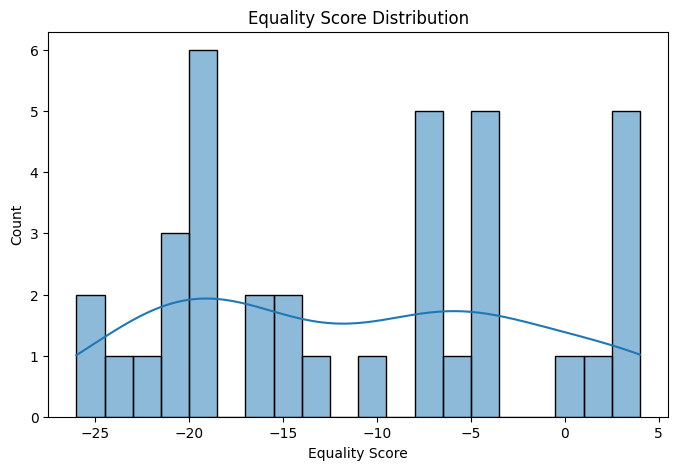

In [ ]:
#Equality Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Equality Score'], bins=20, kde=True)
plt.title("Equality Score Distribution")
plt.show()

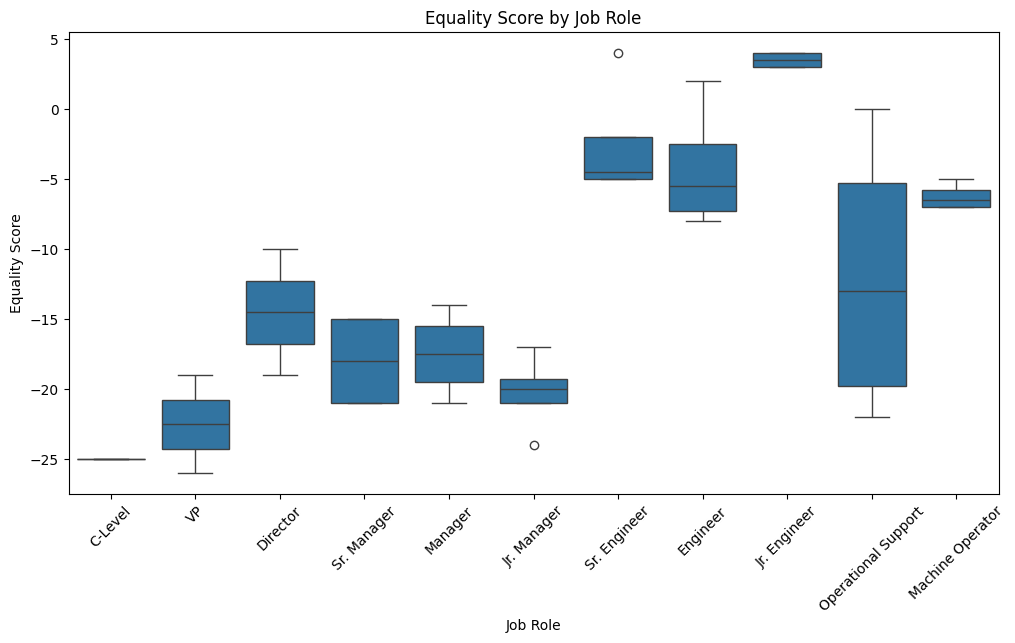

In [ ]:
#Equality Score by Job Role
plt.figure(figsize=(12,6))
sns.boxplot(x='Job Role', y='Equality Score', data=df)
plt.xticks(rotation=45)
plt.title("Equality Score by Job Role")
plt.show()

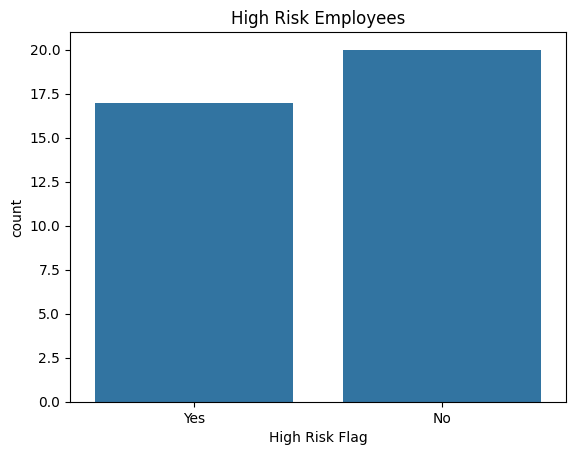

In [ ]:
#High Risk Employees Count
sns.countplot(x='High Risk Flag', data=df)
plt.title("High Risk Employees")
plt.show()

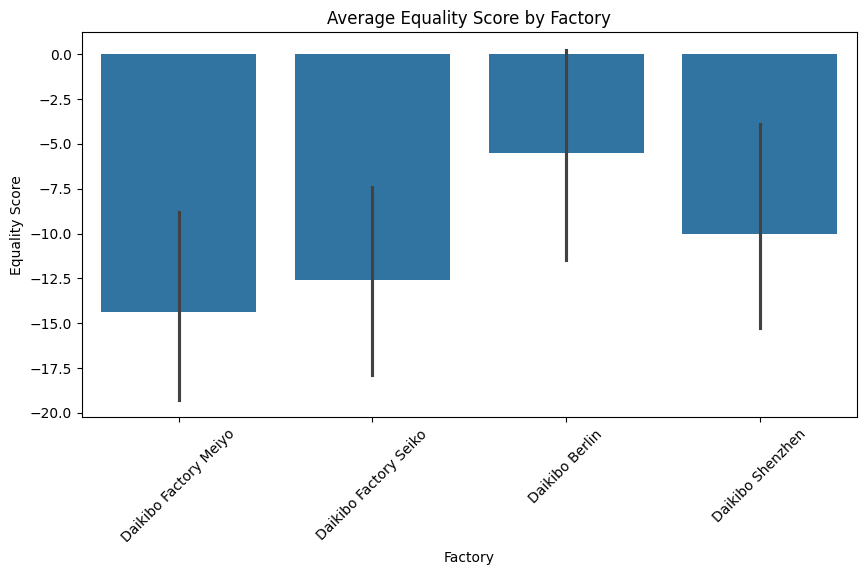

In [ ]:
#Factory-wise Fairness
plt.figure(figsize=(10,5))
sns.barplot(x='Factory', y='Equality Score', data=df)
plt.xticks(rotation=45)
plt.title("Average Equality Score by Factory")
plt.show()

**Group Analysis**

In [ ]:
#Average score by role
role_analysis = df.groupby('Job Role')['Equality Score'].mean().sort_values()
print(role_analysis)

Job Role
C-Level               -25.00
VP                    -22.50
Jr. Manager           -20.25
Sr. Manager           -18.00
Manager               -17.50
Director              -14.50
Operational Support   -12.00
Machine Operator       -6.25
Engineer               -4.25
Sr. Engineer           -2.50
Jr. Engineer            3.50
Name: Equality Score, dtype: float64


In [ ]:
#Factory risk analysis
risk_analysis = df.groupby('Factory')['High Risk Flag'].value_counts()
print(risk_analysis)

Factory                High Risk Flag
Daikibo Berlin         No                5
                       Yes               3
Daikibo Factory Meiyo  Yes               6
                       No                5
Daikibo Factory Seiko  No                5
                       Yes               5
Daikibo Shenzhen       No                5
                       Yes               3
Name: count, dtype: int64


**BASIC MACHINE LEARNING CONCEPTS**

In [14]:
#Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Factory', 'Job Role', 'High Risk Flag', 'Fairness Band', 'Equality class']:
    df[col] = le.fit_transform(df[col])

print(df['Factory'].unique())

[1 2 0 3]


In [15]:
#Define Features & Target
X = df[['Factory', 'Job Role', 'Equality Score', 'Role Level', 'Fairness Band']]
y = df['High Risk Flag']

print(X.head())
print(y.head())

   Factory  Job Role  Equality Score         Role Level  Fairness Band
0        1         0             -25          Executive              0
1        1        10             -26          Executive              0
2        1         1             -19  Senior Leadership              1
3        1         9             -15     Mid Management              1
4        1         6             -14     Mid Management              1
0    1
1    1
2    1
3    1
4    0
Name: High Risk Flag, dtype: int64


In [16]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (29, 5)
X_test shape: (8, 5)


In [8]:
#Train Model (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# The error indicates 'Role Level' column in X_train is still categorical (string)
# It needs to be converted to numerical.

# Create a LabelEncoder instance
le_role_level = LabelEncoder()

# Fit the encoder on the combined 'Role Level' from both train and test sets
# to ensure consistent mapping of categories across both sets.
combined_role_level = pd.concat([X_train['Role Level'], X_test['Role Level']], axis=0)
le_role_level.fit(combined_role_level)

# Transform the 'Role Level' column in X_train and X_test
X_train.loc[:, 'Role Level'] = le_role_level.transform(X_train['Role Level'])
X_test.loc[:, 'Role Level'] = le_role_level.transform(X_test['Role Level'])

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [9]:
#Predictions
y_pred = model.predict(X_test)

In [10]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.875
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.67      1.00      0.80         2

    accuracy                           0.88         8
   macro avg       0.83      0.92      0.85         8
weighted avg       0.92      0.88      0.88         8



In [11]:
#Feature Importance
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

          Feature  Importance
2  Equality Score    0.459030
4   Fairness Band    0.277881
3      Role Level    0.180721
1        Job Role    0.058517
0         Factory    0.023852


**Convert Categorical Data (for ML)**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['High Risk Flag'] = le.fit_transform(df['High Risk Flag'])
print("High Risk Flag:", df['High Risk Flag'].unique())

df['Equality class'] = le.fit_transform(df['Equality class'])
print("Equality class:", df['Equality class'].unique())

df['Fairness Band'] = le.fit_transform(df['Fairness Band'])
print("Fairness Band:", df['Fairness Band'].unique())

df['Job Role'] = le.fit_transform(df['Job Role'])
print("Job Role:", df['Job Role'].unique())

df['Factory'] = le.fit_transform(df['Factory'])
print("Factory:", df['Factory'].unique())

High Risk Flag: [1 0]
Equality class: [1 2 0]
Fairness Band: [0 1 3 2]
Job Role: [ 0 10  1  9  6  4  8  2  3  7  5]
Factory: [1 2 0 3]


**Simple ML Model (Predict High Risk)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# 🔧 1. Drop useless column
df = df.drop('Employee Name', axis=1)

# 🔧 2. Encode target column
df['High Risk Flag'] = LabelEncoder().fit_transform(df['High Risk Flag'])

# 🔧 3. Convert ALL categorical columns automatically
df = pd.get_dummies(df)

# 🔍 Debug (VERY IMPORTANT)
print(df.dtypes)

# Features & target
X = df.drop('High Risk Flag', axis=1)
y = df['High Risk Flag']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Equality Score                  int64
Equality class                  int64
High Risk Flag                  int64
Factory_0                        bool
Factory_1                        bool
Factory_2                        bool
Factory_3                        bool
Job Role_0                       bool
Job Role_1                       bool
Job Role_2                       bool
Job Role_3                       bool
Job Role_4                       bool
Job Role_5                       bool
Job Role_6                       bool
Job Role_7                       bool
Job Role_8                       bool
Job Role_9                       bool
Job Role_10                      bool
Fairness Band_0                  bool
Fairness Band_1                  bool
Fairness Band_2                  bool
Fairness Band_3                  bool
Role Level_Executive             bool
Role Level_Mid Management        bool
Role Level_Other                 bool
Role Level_Senior Leadership     bool
dtype: objec

**Feature Importance**

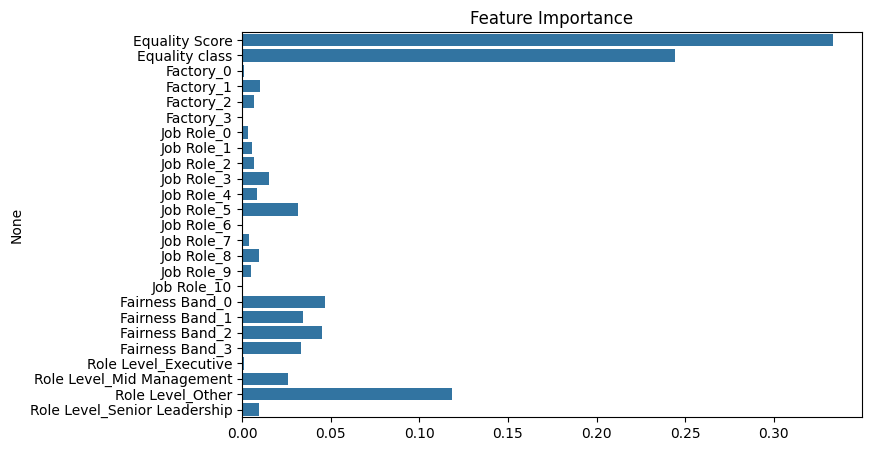

In [ ]:
importances = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()